<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/gymnasium/wip_solving_lunarlander_v3_a2c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install swig
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp311-cp311-linux_x86_64.whl size=2379443 sha256=a22e788bd84ce594ed7ab7e7978109a45eba97f06e845cb896a72f2582e23159
  Stored in directory: /root/.cache/pip/wheels/ab/f1/0c/d56f4a2bdd12bae0a0693ec33f2f0daadb5eb9753c78fa5308
Successfully built box2d-py


Using device: cpu
Episode 10, Score: -275.20, Avg Score (100): -220.20, Loss: 0.3615
Episode 20, Score: -172.79, Avg Score (100): -203.47, Loss: 0.2991
Episode 30, Score: -184.77, Avg Score (100): -196.25, Loss: 0.4657
Episode 40, Score: -253.72, Avg Score (100): -209.99, Loss: 0.0365
Episode 50, Score: -354.74, Avg Score (100): -227.83, Loss: 0.3682
Episode 60, Score: -114.89, Avg Score (100): -230.96, Loss: 0.6082
Episode 70, Score: -314.30, Avg Score (100): -227.59, Loss: 0.2079
Episode 80, Score: -133.55, Avg Score (100): -216.86, Loss: 0.0295
Episode 90, Score: -0.50, Avg Score (100): -204.16, Loss: 0.5576
Episode 100, Score: -98.33, Avg Score (100): -195.34, Loss: 0.0073
Episode 110, Score: -241.62, Avg Score (100): -192.93, Loss: 0.6631
Episode 120, Score: -350.46, Avg Score (100): -185.47, Loss: 0.0419
Episode 130, Score: -95.42, Avg Score (100): -179.83, Loss: 0.0424
Episode 140, Score: -319.38, Avg Score (100): -167.81, Loss: 0.2128
Episode 150, Score: -276.06, Avg Score (100

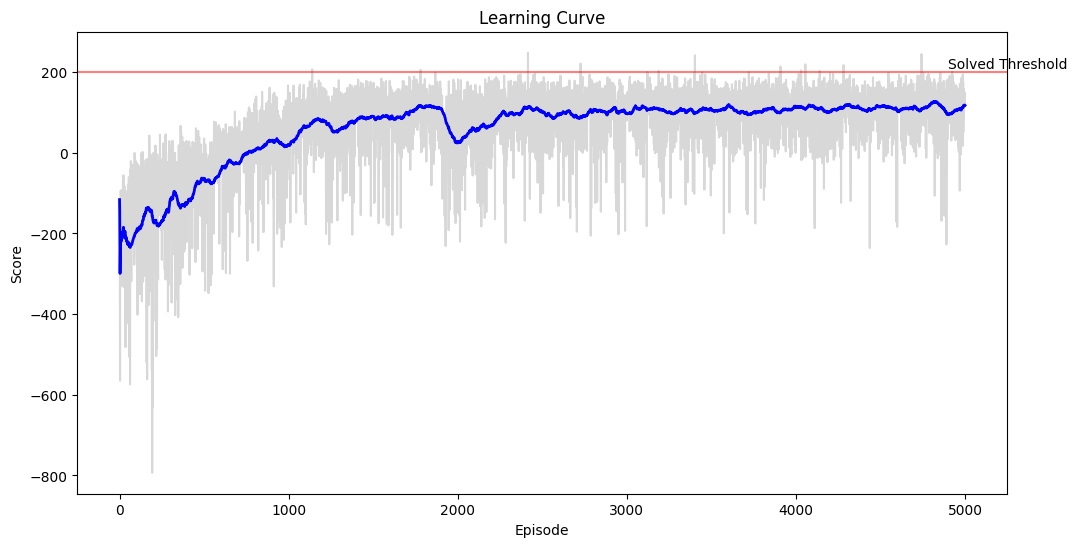

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from collections import deque

# Hyperparameters
GAMMA = 0.99
LEARNING_RATE = 0.001
ENTROPY_COEFF = 0.01
MAX_EPISODES = 10000
SOLVED_SCORE = 200
VALUE_COEFF = 0.5
CLIP_GRAD = 0.5

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()

        # Common layers
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 256)

        # Actor head (policy)
        self.actor = nn.Linear(256, action_dim)

        # Critic head (value function)
        self.critic = nn.Linear(256, 1)

        # Weight initialization
        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                layer.bias.data.zero_()

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        # Actor: action probabilities
        action_probs = F.softmax(self.actor(x), dim=-1)

        # Critic: state value
        state_value = self.critic(x)

        return action_probs, state_value

def train():
    # Create environment
    env = gym.make("LunarLander-v3")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Device configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Create model and optimizer
    model = ActorCritic(state_dim, action_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Tracking variables
    scores = []
    avg_scores = []
    recent_scores = deque(maxlen=100)

    for episode in range(1, MAX_EPISODES + 1):
        state, _ = env.reset()
        score = 0
        done = False

        # Lists to store episode data
        states = []
        actions = []
        rewards = []
        dones = []

        while not done:
            # Convert state to tensor
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

            # Get action probabilities and state value
            with torch.no_grad():  # No gradients needed for action selection
                action_probs, state_value = model(state_tensor)

            # Sample action from the probability distribution
            dist = Categorical(action_probs)
            action = dist.sample().item()

            # Take action in the environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Store experience
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            dones.append(done)

            # Update for next iteration
            state = next_state
            score += reward

        # Episode completed - now do the learning

        # Convert to tensors
        states_tensor = torch.FloatTensor(np.array(states)).to(device)
        actions_tensor = torch.LongTensor(actions).to(device)

        # Get action probabilities and state values for all states
        action_probs, state_values = model(states_tensor)
        state_values = state_values.squeeze()

        # Get log probabilities of actions taken
        dist = Categorical(action_probs)
        log_probs = dist.log_prob(actions_tensor)
        entropy = dist.entropy().mean()

        # Compute returns with discounted rewards
        returns = []
        discounted_reward = 0

        for reward, done in zip(reversed(rewards), reversed(dones)):
            if done:
                discounted_reward = 0
            discounted_reward = reward + GAMMA * discounted_reward
            returns.insert(0, discounted_reward)

        returns = torch.FloatTensor(returns).to(device)

        # Normalize returns (helps with training stability)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Compute advantage (returns - baseline)
        advantage = returns - state_values.detach()

        # Compute losses
        actor_loss = -(log_probs * advantage).mean()
        critic_loss = VALUE_COEFF * F.mse_loss(state_values, returns)
        entropy_loss = -ENTROPY_COEFF * entropy

        # Total loss
        loss = actor_loss + critic_loss + entropy_loss

        # Update network
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()

        # Update tracking variables
        scores.append(score)
        recent_scores.append(score)
        avg_score = np.mean(recent_scores)
        avg_scores.append(avg_score)

        # Print progress
        if episode % 10 == 0:
            print(f"Episode {episode}, Score: {score:.2f}, Avg Score (100): {avg_score:.2f}, Loss: {loss.item():.4f}")

        # Check if solved
        if len(recent_scores) == 100 and avg_score >= SOLVED_SCORE:
            print(f"\nEnvironment solved in {episode} episodes! Average Score: {avg_score:.2f}")
            torch.save(model.state_dict(), 'lunar_lander_solved.pt')
            break

    # Plot learning curve
    plt.figure(figsize=(12, 6))
    plt.plot(scores, alpha=0.3, color='gray')
    plt.plot(avg_scores, color='blue', linewidth=2)
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.title('Learning Curve')
    plt.axhline(y=200, color='r', linestyle='-', alpha=0.5)
    plt.text(len(scores)-100, 210, 'Solved Threshold')
    plt.savefig('learning_curve.png')
    plt.show()

    return model

if __name__ == "__main__":
    train()